In [66]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

# Load data
(x_train, _), (_, _) = fashion_mnist.load_data()

# Normalize to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

print("x_train shape:", x_train.shape)

# Settings
noise_dim = 100
img_shape = (28, 28, 1)

# Generator
generator = Sequential([
    Dense(256, input_shape=(noise_dim,)),
    LeakyReLU(negative_slope=0.2),

    Dense(512),
    LeakyReLU(negative_slope=0.2),

    Dense(1024),
    LeakyReLU(negative_slope=0.2),

    Dense(28 * 28 * 1, activation="tanh"),
    Reshape(img_shape)
])

# Discriminator
discriminator = Sequential([
    Flatten(input_shape=img_shape),

    Dense(512),
    LeakyReLU(negative_slope=0.2),

    Dense(256),
    LeakyReLU(negative_slope=0.2),

    Dense(1, activation="sigmoid")
])

# Optimizers
d_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

# Compile discriminator first
discriminator.compile(
    loss="binary_crossentropy",
    optimizer=d_optimizer,
    metrics=["accuracy"]
)

# Build GAN
discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    loss="binary_crossentropy",
    optimizer=g_optimizer
)

print("Generator summary:")
generator.summary()

print("Discriminator summary:")
discriminator.summary()

print("GAN summary:")
gan.summary()

print("Generator trainable weights:", len(generator.trainable_weights))
print("Discriminator trainable weights:", len(discriminator.trainable_weights))
print("GAN trainable weights:", len(gan.trainable_weights))

x_train shape: (60000, 28, 28, 1)
Generator summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │     1,486,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,857 (7.71 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 533,505 (2.04 MB)

Generator trainable weights: 8
Discriminator trainable weights: 0
GAN trainable weights: 8


Epoch 0 | D real loss: 0.4859, acc: 0.8203 | D fake loss: 0.6160, acc: 0.5078 | G loss: 0.7266


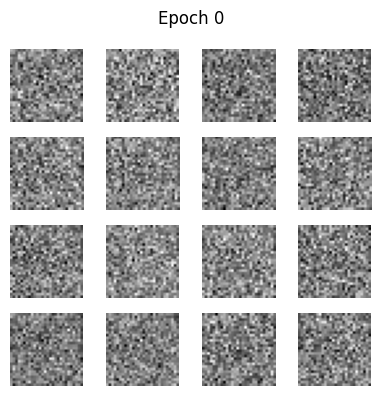

Epoch 500 | D real loss: 0.4633, acc: 0.7831 | D fake loss: 0.4634, acc: 0.7831 | G loss: 1.3233


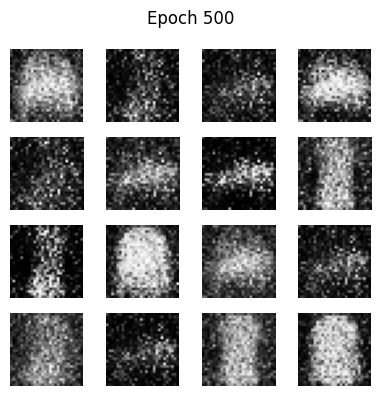

Epoch 1000 | D real loss: 0.5191, acc: 0.7388 | D fake loss: 0.5191, acc: 0.7388 | G loss: 1.2599


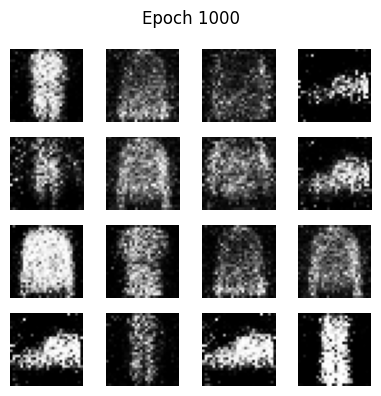

Epoch 1500 | D real loss: 0.5524, acc: 0.7081 | D fake loss: 0.5525, acc: 0.7081 | G loss: 1.1789


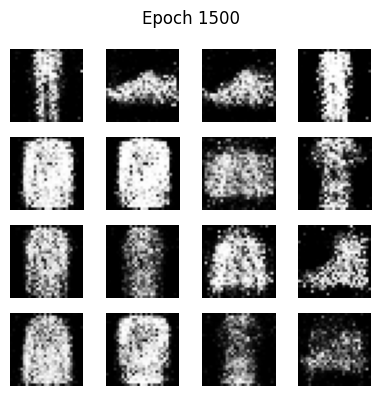

Epoch 2000 | D real loss: 0.5758, acc: 0.6852 | D fake loss: 0.5758, acc: 0.6852 | G loss: 1.1176


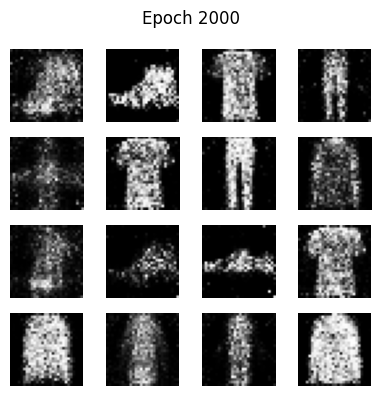

Epoch 2500 | D real loss: 0.5921, acc: 0.6695 | D fake loss: 0.5921, acc: 0.6695 | G loss: 1.0728


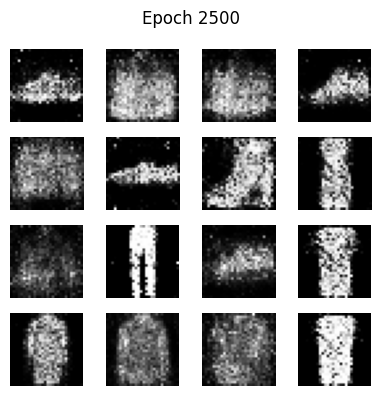

Epoch 3000 | D real loss: 0.6028, acc: 0.6590 | D fake loss: 0.6028, acc: 0.6590 | G loss: 1.0432


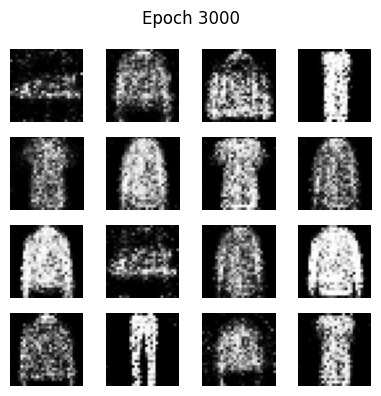

In [67]:
def show_generated_images(epoch, generator, noise_dim, examples=16):
    noise = np.random.normal(0, 1, (examples, noise_dim))
    generated_images = generator.predict(noise, verbose=0)

    # Convert from [-1, 1] to [0, 1] for display
    generated_images = 0.5 * generated_images + 0.5

    plt.figure(figsize=(4, 4))

    for i in range(examples):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()


epochs = 3000
batch_size = 128
sample_interval = 500

for epoch in range(epochs + 1):

    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_images = generator.predict(noise, verbose=0)

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    valid_labels = np.ones((batch_size, 1))

    discriminator.trainable = False

    g_loss = gan.train_on_batch(noise, valid_labels)

    if epoch % sample_interval == 0:
        print(
            f"Epoch {epoch} | "
            f"D real loss: {d_loss_real[0]:.4f}, acc: {d_loss_real[1]:.4f} | "
            f"D fake loss: {d_loss_fake[0]:.4f}, acc: {d_loss_fake[1]:.4f} | "
            f"G loss: {g_loss:.4f}"
        )

        show_generated_images(epoch, generator, noise_dim)